<a href="https://colab.research.google.com/github/AHANIK33/Machine-Learning/blob/main/Student_result_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,LabelEncoder,StandardScaler,MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error,r2_score,root_mean_squared_error,mean_absolute_error
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

In [6]:
df = pd.read_csv("/content/students.csv")

In [7]:
df

,student_id,age,gender,ethnicity,parental_education,family_income,school_type,school_region,study_hours_per_week,attendance_rate,...,has_laptop,sleep_hours,stress_level,motivation_score,reading_score,writing_score,math_score,science_score,overall_gpa,passed
0,STU00000,15,M,B,phd,low,private,urban,2.0,91.7,...,yes,8.2,3.3,1.8,70.7,58.3,88.9,74.5,2.80,1
1,STU00001,23,F,A,phd,low,private,urban,14.2,76.8,...,yes,5.4,4.9,5.8,66.1,83.9,94.5,83.6,3.29,1
2,STU00002,22,F,B,bachelor,middle,public,suburban,3.3,83.1,...,yes,5.5,3.5,6.1,51.3,71.8,78.9,71.2,2.93,1
3,STU00003,19,M,D,some_college,high,public,suburban,17.9,72.8,...,yes,5.3,8.5,7.2,100.0,95.7,82.9,69.4,3.34,1
4,STU00004,19,M,C,some_college,middle,public,suburban,12.9,83.0,...,yes,7.5,1.0,4.5,87.5,73.0,88.5,74.8,3.27,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,STU09995,20,F,A,bachelor,low,public,urban,13.8,85.4,...,yes,6.6,7.4,8.1,78.1,66.6,83.2,82.7,3.07,1
9996,STU09996,25,F,C,master,high,public,urban,8.5,97.4,...,yes,7.0,2.1,7.1,100.0,89.0,93.0,100.0,3.72,1
9997,STU09997,18,M,C,some_college,middle,private,suburban,13.9,81.1,...,no,7.3,5.0,1.7,90.7,91.1,73.0,80.6,3.20,1
9998,STU09998,21,M,B,high_school,low,charter,suburban,3.6,79.1,...,yes,7.3,5.4,4.5,73.8,68.8,57.5,89.5,2.76,1


In [10]:
df.sample(10)

,student_id,age,gender,ethnicity,parental_education,family_income,school_type,school_region,study_hours_per_week,attendance_rate,...,has_laptop,sleep_hours,stress_level,motivation_score,reading_score,writing_score,math_score,science_score,overall_gpa,passed
1547,STU01547,24,F,C,bachelor,middle,private,urban,8.4,90.4,...,yes,6.0,6.3,5.0,66.3,55.4,69.2,85.0,2.64,1
5663,STU05663,19,F,B,bachelor,middle,public,urban,15.5,87.2,...,yes,7.3,2.4,2.2,85.3,99.0,100.0,100.0,3.78,1
8433,STU08433,22,F,C,some_college,high,public,rural,11.4,86.6,...,yes,7.7,2.9,9.7,94.4,94.7,100.0,90.8,3.93,1
6804,STU06804,19,F,B,some_college,middle,public,urban,8.4,82.5,...,yes,6.7,4.5,7.6,87.4,93.7,100.0,100.0,4.00,1
1476,STU01476,20,F,D,bachelor,middle,charter,suburban,14.9,70.8,...,yes,6.0,4.2,3.3,73.1,57.3,58.5,82.3,2.52,1
5047,STU05047,21,M,A,phd,middle,public,suburban,14.9,83.1,...,yes,6.5,4.8,5.6,61.4,55.6,87.2,92.7,2.89,1
4243,STU04243,15,M,D,high_school,middle,public,suburban,17.7,71.3,...,yes,6.7,4.0,5.2,64.8,78.2,84.1,87.7,2.85,1
2416,STU02416,21,M,A,some_college,middle,public,urban,6.4,81.1,...,no,6.0,4.3,4.6,58.8,53.2,58.2,59.5,2.41,1
8673,STU08673,15,M,E,master,middle,public,urban,18.6,83.8,...,yes,6.9,3.9,4.0,100.0,100.0,82.2,96.1,3.85,1
3384,STU03384,23,M,C,high_school,middle,public,suburban,6.2,88.6,...,yes,7.9,3.3,9.6,63.0,82.4,83.1,77.3,3.08,1


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  10000 non-null  object 
 1   age                         10000 non-null  int64  
 2   gender                      10000 non-null  object 
 3   ethnicity                   10000 non-null  object 
 4   parental_education          10000 non-null  object 
 5   family_income               10000 non-null  object 
 6   school_type                 10000 non-null  object 
 7   school_region               10000 non-null  object 
 8   study_hours_per_week        10000 non-null  float64
 9   attendance_rate             10000 non-null  float64
 10  extracurricular_activities  10000 non-null  int64  
 11  sports_participation        10000 non-null  object 
 12  tutoring_sessions           10000 non-null  int64  
 13  parental_involvement        1000

In [16]:
df['ethnicity'].unique()

array(['B', 'A', 'D', 'C', 'E'], dtype=object)

In [19]:
df['parental_education'].unique()

array(['phd', 'bachelor', 'some_college', 'high_school', 'master', 'none'],
      dtype=object)

In [20]:
df['family_income'].unique()

array(['low', 'middle', 'high'], dtype=object)

In [21]:
df['school_region'].unique()

array(['urban', 'suburban', 'rural'], dtype=object)

In [23]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
ethnicity,0
parental_education,0
family_income,0
school_type,0
school_region,0
study_hours_per_week,0
attendance_rate,0


In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
df.drop_duplicates(inplace=True)

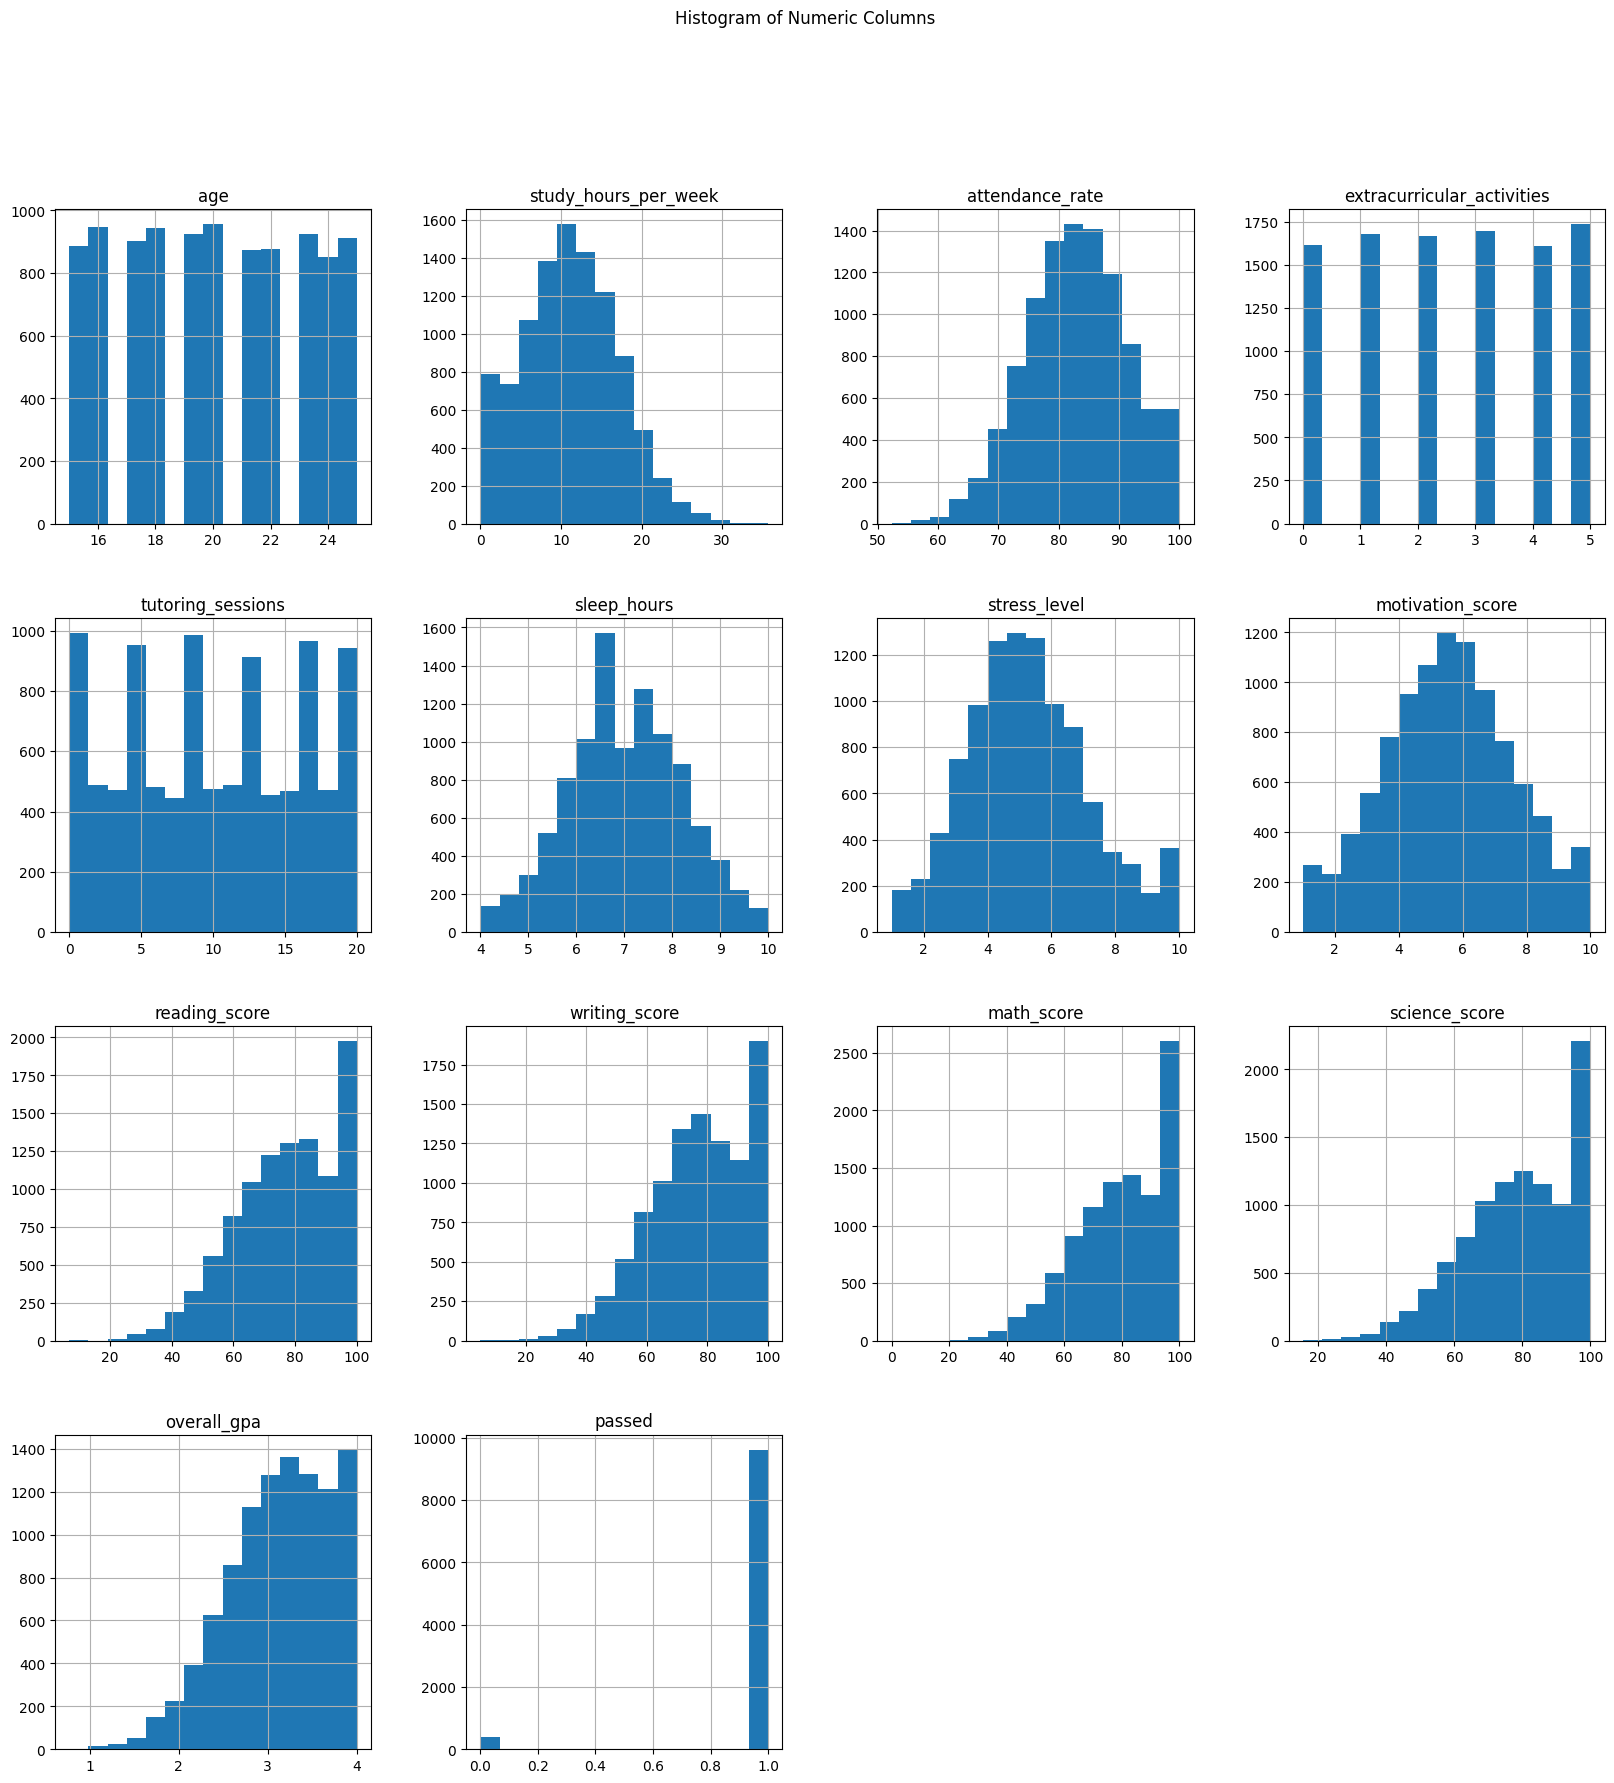

In [29]:
df.hist(bins=15,figsize=(20,20))
plt.suptitle('Histogram of Numeric Columns')
plt.show()

In [60]:
numerical_columns = ['math_score','reading_score','writing_score','sleep_hours','stress_level','motivation_score','science_score','overall_gpa']

In [61]:
df[numerical_columns].corr()

,math_score,reading_score,writing_score,sleep_hours,stress_level,motivation_score,science_score,overall_gpa
math_score,1.000000,0.678912,0.682088,0.155659,-0.191713,0.261091,0.699486,0.849062
reading_score,0.678912,1.000000,0.679677,0.153808,-0.199227,0.258479,0.682469,0.842684
writing_score,0.682088,0.679677,1.000000,0.172530,-0.208719,0.266842,0.682152,0.842451
sleep_hours,0.155659,0.153808,0.172530,1.000000,-0.339656,-0.006042,0.159788,0.176372
stress_level,-0.191713,-0.199227,-0.208719,-0.339656,1.000000,-0.007223,-0.197077,-0.218724
motivation_score,0.261091,0.258479,0.266842,-0.006042,-0.007223,1.000000,0.273870,0.294462
science_score,0.699486,0.682469,0.682152,0.159788,-0.197077,0.273870,1.000000,0.849155
overall_gpa,0.849062,0.842684,0.842451,0.176372,-0.218724,0.294462,0.849155,1.000000


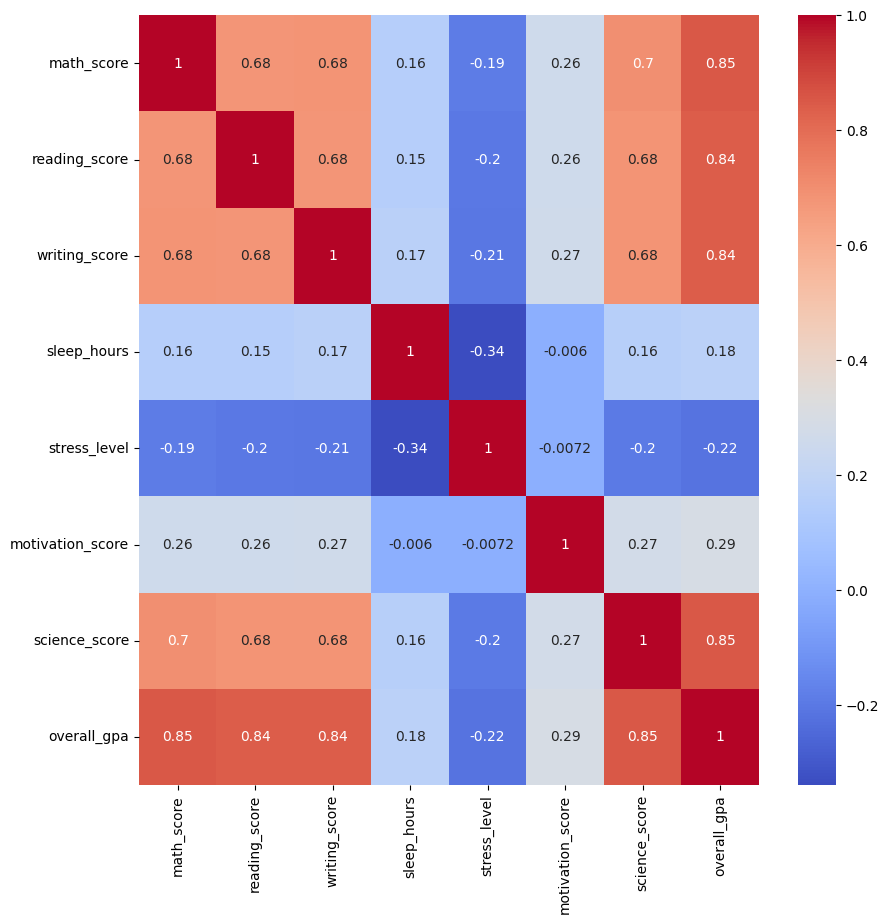

In [62]:
plt.figure(figsize=(10,10))
sns.heatmap(df[numerical_columns].corr(),annot=True,cmap='coolwarm')
plt.show()

In [63]:
numerical_transformers = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='mean')),
    ('scaler',StandardScaler())
])

In [64]:
nominal_columns = ['ethnicity','parental_education','family_income','school_region','school_type','gender','has_laptop']
nominal_transformers = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder())
])

In [65]:
preprocessor = ColumnTransformer(transformers=[
    ('nominal',nominal_transformers,nominal_columns),
    ('numerical',numerical_transformers,numerical_columns)
])

In [66]:
preprocessor

ColumnTransformer(transformers=[('nominal',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder', OneHotEncoder())]),
                                 ['ethnicity', 'parental_education',
                                  'family_income', 'school_region',
                                  'school_type', 'gender', 'has_laptop']),
                                ('numerical',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['math_score', 'reading_score',
                                  'writing_score', 'sleep_hours',
                                  'stress_level', 'motivation_score',
                                  'science_score', 'overall_gpa'])])

In [67]:
x = df.drop(columns=['passed'])
y = df['passed']

In [68]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [78]:
svc_pipeline = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',SVC())
])

grid = [{
    'model__C':[0.1,1,10,100],
    'model__kernel':['linear']
},
      {
          'model__C':[0.1,1,10,100],
      'model__kernel':['rbf'],
          'model__gamma':[0.1,1,10,100]
      },
      {
          'model__C':[0.1,1,10,100],
          'model__kernel':['poly'],
          'model__degree':[2,3,4]
      }

]

In [93]:
best_svc_model = GridSearchCV(estimator=svc_pipeline,param_grid=grid,cv=5)
best_svc_model.fit(X_train,y_train)
best_svc_model.predict(X_train)
y_pred=best_svc_model.predict(X_test)

In [94]:
print(f"MSE: {mean_squared_error(y_test,svc_pipeline.predict(X_test))}")
print(f"R2: {r2_score(y_test,svc_pipeline.predict(X_test))}")
print(f"RMSE: {root_mean_squared_error(y_test,svc_pipeline.predict(X_test))}")
print(f"MAE: {mean_absolute_error(y_test,svc_pipeline.predict(X_test))}")
print(f"Accuracy: {accuracy_score(y_test,y_pred)}")

MSE: 0.0075
R2: 0.8135997614076946
RMSE: 0.08660254037844387
MAE: 0.0075
Accuracy: 0.997


In [95]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',LogisticRegression())
])
lr_pipeline.fit(X_train,y_train)
lr_pipeline.predict(X_train)
y_pred2=lr_pipeline.predict(X_test)

In [96]:
print(f"MSE: {mean_squared_error(y_test,lr_pipeline.predict(X_test))}")
print(f"R2: {r2_score(y_test,lr_pipeline.predict(X_test))}")
print(f"RMSE: {root_mean_squared_error(y_test,lr_pipeline.predict(X_test))}")
print(f"MAE: {mean_absolute_error(y_test,lr_pipeline.predict(X_test))}")
print(f"Accuracy: {accuracy_score(y_test,y_pred2)}")

MSE: 0.0045
R2: 0.8881598568446167
RMSE: 0.0670820393249937
MAE: 0.0045
Accuracy: 0.9955


In [97]:
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(result)

      Actual  Predicted
0          1          1
1          1          1
2          1          1
3          1          1
4          1          1
...      ...        ...
1995       1          1
1996       1          1
1997       1          1
1998       1          1
1999       1          1

[2000 rows x 2 columns]


In [99]:
result.head(30)

,Actual,Predicted
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
5,1,1
6,1,1
7,1,1
8,1,1
9,1,1


SVM Model is better